# Aggregate Production Planning with Workforce, Overtime and Backlogs

**Problem.** An electronics manufacturer builds four types of flat-screen television and needs an aggregate production plan for the next 12 months. Rather than plan each model separately, the four are collapsed into a single **aggregate unit** weighted by sales mix, so one aggregate unit represents the average television the company sells.

The company employs 25 workers at 190 hours a month and `$25` an hour. A labour agreement rules out hiring and layoffs. Each worker may work up to 5 hours of overtime a month at `$30` an hour. Holding a television costs `$6` a month; backlogging unmet demand costs `$12` a month. The company starts January with 300 units of inventory and no backlog, and wants to end December in the same position.

**Question:** what production, inventory and overtime plan meets demand at minimum cost, and how does that plan change when the rules change?

The notebook builds the base plan, then re-solves it under four independent scenarios: adjustable workforce, a much higher holding cost, and two alternative promotion timings.

## Formulation

**Parameters.**

| Symbol | Meaning |
| --- | --- |
| $D_t$ | Aggregate demand in month $t$ |
| $\lambda$ | Units one worker produces per month on regular time |
| $\rho$ | Units produced per overtime hour |
| $c_H, c_L$ | Cost of hiring / laying off one worker |
| $c_W$ | Cost of one worker for one month |
| $c_O$ | Overtime cost per hour |
| $c_I, c_S$ | Holding cost and backlog cost per unit per month |
| $c_P$ | Material cost per aggregate unit |

**Decision variables**, all for $t = 1, \ldots, 12$:

| Symbol | Meaning |
| --- | --- |
| $H_t$ | Workers hired at the beginning of month $t$ |
| $L_t$ | Workers laid off at the beginning of month $t$ |
| $W_t$ | Workforce size in month $t$ |
| $O_t$ | Overtime hours worked in month $t$ |
| $I_t$ | Inventory at the end of month $t$ |
| $S_t$ | Units backlogged at the end of month $t$ |
| $P_t$ | Units produced in month $t$ |

**Model.**

$$
\begin{aligned}
\min \quad & \sum_t \big( c_H H_t + c_L L_t + c_W W_t + c_O O_t + c_I I_t + c_S S_t + c_P P_t \big) \\
\text{s.t.}\quad
& W_t - W_{t-1} - H_t + L_t = 0 && \forall t && \text{(workforce balance)}\\
& P_t - \lambda W_t - \rho\, O_t \le 0 && \forall t && \text{(production capacity)}\\
& I_{t-1} + P_t - D_t - S_{t-1} - I_t + S_t = 0 && \forall t && \text{(inventory balance)}\\
& O_t - 5 W_t \le 0 && \forall t && \text{(overtime limit)}\\
& H_t, L_t, W_t, O_t, I_t, S_t, P_t \ge 0, \quad \quad H_t, L_t \text{ integer}
\end{aligned}
$$

with $W_0 = W_{12} = 25$, $I_0 = I_{12} = 300$, and $S_0 = S_{12} = 0$.

The labour agreement is modelled by pricing hiring and layoffs at a prohibitive $10^6$ per worker rather than by fixing $H_t = L_t = 0$. That keeps the same model usable for the adjustable-workforce scenario later.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. Building the aggregate unit

Before planning, the four television types have to be collapsed into one. Each figure is a sales-mix weighted average.

**Net production time** per type is the run time per unit, and it also carries that type's share of the setup, amortised over an average batch:

$$
\text{net time per unit} = \text{production time} + \frac{\text{setup time per batch}}{\text{average batch size}}
$$

In [2]:
tv = pd.DataFrame([
        ("A", 450, 650, 3, 20, 2.7, 0.3),
        ("B", 150, 450, 5, 40, 1.8, 0.2),
        ("C", 200, 500, 1, 25, 1.6, 0.2),
        ("D", 350, 700, 2, 50, 1.4, 0.3)],
    columns=["type", "material_cost", "revenue", "setup_hrs_per_batch",
             "avg_batch_size", "prod_time_per_unit", "share_of_units_sold"],
).set_index("type")

tv["net_time_per_unit"] = tv.prod_time_per_unit + tv.setup_hrs_per_batch / tv.avg_batch_size
tv

,material_cost,revenue,setup_hrs_per_batch,avg_batch_size,prod_time_per_unit,share_of_units_sold,net_time_per_unit
type,,,,,,,
A,450,650,3,20,2.7,0.3,2.850
B,150,450,5,40,1.8,0.2,1.925
C,200,500,1,25,1.6,0.2,1.640
D,350,700,2,50,1.4,0.3,1.440


In [3]:
MATERIAL_COST = float((tv.material_cost * tv.share_of_units_sold).sum())
REVENUE       = float((tv.revenue * tv.share_of_units_sold).sum())
NET_TIME      = float((tv.net_time_per_unit * tv.share_of_units_sold).sum())

pd.Series({
    "Material cost ($/aggregate unit)": MATERIAL_COST,
    "Revenue ($/aggregate unit)": REVENUE,
    "Net production time (hrs/aggregate unit)": NET_TIME,
}).to_frame("Aggregate unit")

,Aggregate unit
Material cost ($/aggregate unit),310.0
Revenue ($/aggregate unit),595.0
Net production time (hrs/aggregate unit),2.0


The aggregate unit costs `$310` in materials, sells for `$595`, and takes exactly 2 hours to produce. That last figure sets the capacity conversion used throughout: a worker putting in 190 regular hours makes 95 units a month, and each overtime hour adds half a unit.

## 2. Data and cost parameters

In [4]:
MONTHS = list(range(1, 13))
MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

demand = pd.Series(
    [2000, 1500, 1600, 2200, 2500, 1200, 1800, 2000, 2200, 2500, 3000, 2800],
    index=MONTHS, name="demand")

HOURS_PER_MONTH = 190
WAGE_PER_HOUR = 25
WORKER_COST = HOURS_PER_MONTH * WAGE_PER_HOUR     # $ per worker per month
OT_RATE = 30                                      # $ per overtime hour
MAX_OT  = 5                                       # hours per worker per month

WORKER_UNITS = HOURS_PER_MONTH / NET_TIME           # regular-time units per worker
OT_UNITS = 1 / NET_TIME                             # units per overtime hour

BIG_M = 1e6        # used to price out hiring/layoffs under the labour agreement

pd.DataFrame({"Month": MONTH_NAMES, "Demand": demand.values}, index=MONTHS).T

,1,2,3,4,5,6,7,8,9,10,11,12
Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Demand,2000,1500,1600,2200,2500,1200,1800,2000,2200,2500,3000,2800


In [5]:
print(f"Total demand            : {demand.sum():,} units")
print(f"Worker cost             : ${WORKER_COST:,}/month")
print(f"Regular units per worker: {WORKER_UNITS:.0f}/month")
print(f"Units per overtime hour : {OT_UNITS:.1f}")
print(f"Capacity at 25 workers  : {25 * WORKER_UNITS:,.0f} units/month "
      f"(+{25 * MAX_OT * OT_UNITS:,.1f} on full overtime)")

Total demand            : 25,300 units
Worker cost             : $4,750/month
Regular units per worker: 95/month
Units per overtime hour : 0.5
Capacity at 25 workers  : 2,375 units/month (+62.5 on full overtime)


Capacity at the fixed workforce is 2,375 units a month, rising to 2,437.5 with every worker on full overtime. Demand exceeds even that ceiling in November (3,000) and December (2,800), so those months must be served partly from inventory built earlier, hence the plan cannot be made month by month.

## 3. Model

In [6]:
def solve_plan(hire_cost=BIG_M, layoff_cost=BIG_M, holding_cost=6, backlog_cost=12, 
               monthly_demand=None, material_cost=MATERIAL_COST):
    '''
    Solve the aggregate production plan.
    Defaults reproduce the base case, and the published demand forecast.
    '''
    d = demand if monthly_demand is None else monthly_demand

    env = gp.Env(empty=True); env.setParam("OutputFlag", 0); env.start()
    m = gp.Model("aggregate_plan", env=env)
    m.Params.MIPGap = 0       # default 0.01% gap; prove optimality

    H = m.addVars(MONTHS, vtype=GRB.INTEGER, lb=0.0, name="hired")
    L = m.addVars(MONTHS, vtype=GRB.INTEGER, lb=0.0, name="laid_off")
    W = m.addVars(MONTHS, lb=0.0, name="workforce")
    O = m.addVars(MONTHS, lb=0.0, name="overtime_hours")
    I = m.addVars(MONTHS, lb=0.0, name="inventory")
    S = m.addVars(MONTHS, lb=0.0, name="backlog")
    P = m.addVars(MONTHS, lb=0.0, name="production")

    m.setObjective(
        gp.quicksum(hire_cost * H[t] + layoff_cost * L[t] + WORKER_COST * W[t]
                    + OT_RATE * O[t] + holding_cost * I[t] + backlog_cost * S[t]
                    + material_cost * P[t] for t in MONTHS), GRB.MINIMIZE)

    for t in MONTHS:
        prev_W = 25 if t == 1 else W[t - 1]
        prev_I = 300 if t == 1 else I[t - 1]
        prev_S = 0 if t == 1 else S[t - 1]
        m.addConstr(W[t] - prev_W - H[t] + L[t] == 0, name=f"workforce_{t}")
        m.addConstr(P[t] - WORKER_UNITS * W[t] - OT_UNITS * O[t] <= 0, name=f"capacity_{t}")
        m.addConstr(prev_I + P[t] - d[t] - prev_S - I[t] + S[t] == 0, name=f"inventory_{t}")
        m.addConstr(O[t] - MAX_OT * W[t] <= 0, name=f"overtime_{t}")

    m.addConstr(W[12] == 25); m.addConstr(I[12] == 300); m.addConstr(S[12] == 0)

    m.optimize()
    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"no optimal solution (status {m.Status})")

    return {
        "cost": m.ObjVal,
        "demand": d,
        "holding_cost": holding_cost,
        "backlog_cost": backlog_cost,
        "hire_cost": hire_cost,
        "layoff_cost": layoff_cost,
        "table": pd.DataFrame({
            "Month": MONTH_NAMES,
            "Demand": [d[t] for t in MONTHS],
            "Hired": [H[t].X for t in MONTHS],
            "Laid off": [L[t].X for t in MONTHS],
            "Workforce": [W[t].X for t in MONTHS],
            "Overtime hrs": [O[t].X for t in MONTHS],
            "Production": [P[t].X for t in MONTHS],
            "Inventory": [I[t].X for t in MONTHS],
            "Backlog": [S[t].X for t in MONTHS],
        }, index=MONTHS)}

## 4. Solution
`report()` adds the cost breakdown and the revenue side, so each scenario can be compared on profit rather than cost alone, which matters once promotions change both.

In [7]:
class Plan:
    '''A solved aggregate plan, with a cost breakdown and profit.'''

    def __init__(self, raw, discount_month=None, discount=0.0):
        self.cost = raw["cost"]
        self.table = raw["table"]
        t = self.table
        self.breakdown = pd.Series({
            "hiring": raw["hire_cost"] * t["Hired"].sum(),
            "layoffs": raw["layoff_cost"] * t["Laid off"].sum(),
            "wages": WORKER_COST * t["Workforce"].sum(),
            "overtime": OT_RATE * t["Overtime hrs"].sum(),
            "holding": raw["holding_cost"] * t["Inventory"].sum(),
            "Backlog": raw["backlog_cost"] * t["Backlog"].sum(),
            "materials": MATERIAL_COST * t["Production"].sum() })
        
        units_sold = t["Demand"].sum()
        if discount_month is None:
            self.revenue = units_sold * REVENUE
        else:
            discounted = raw["demand"][discount_month]
            self.revenue = (discounted * (REVENUE - discount)
                            + (units_sold - discounted) * REVENUE)
        self.profit = self.revenue - self.cost

    def __repr__(self):
        return f"<Plan: cost ${self.cost:,.0f}, Profit ${self.profit:,.0f}>"

def report(raw, discount_month=None, discount=0.0):
    '''Wrap solve_plan() output into a Plan with cost breakdown and profit.'''
    return Plan(raw, discount_month, discount)

## 5. Base plan

In [8]:
base = report(solve_plan())

print(f"Total cost : ${base.cost:,.0f}")
print(f"Revenue    : ${base.revenue:,.0f}")
print(f"Profit     : ${base.profit:,.0f}")
base.table.round(1)

Total cost : $9,307,300
Revenue    : $15,053,500
Profit     : $5,746,200


,Month,Demand,Hired,Laid off,Workforce,Overtime hrs,Production,Inventory,Backlog
1,Jan,2000,-0.0,-0.0,25.0,0.0,1700.0,0.0,0.0
2,Feb,1500,0.0,-0.0,25.0,0.0,1500.0,0.0,0.0
3,Mar,1600,0.0,-0.0,25.0,0.0,1600.0,0.0,0.0
4,Apr,2200,0.0,-0.0,25.0,0.0,2325.0,125.0,0.0
5,May,2500,0.0,-0.0,25.0,0.0,2375.0,0.0,0.0
6,Jun,1200,0.0,-0.0,25.0,0.0,1550.0,350.0,0.0
7,Jul,1800,0.0,-0.0,25.0,0.0,2375.0,925.0,0.0
8,Aug,2000,0.0,-0.0,25.0,0.0,2375.0,1300.0,0.0
9,Sep,2200,0.0,-0.0,25.0,0.0,2375.0,1475.0,0.0
10,Oct,2500,0.0,-0.0,25.0,0.0,2375.0,1350.0,0.0


The company runs a **level strategy**: the workforce is fixed at 25, no overtime is used anywhere, and no demand is ever backlogged. Instead the plan builds inventory through the quiet first half of the year, peaking at 1,475 units in September, and draws it down across the heavy November and December months.

That is the only workable answer given the constraints. With hiring and layoffs priced out and capacity capped at 2,375 units a month, inventory is the sole remaining lever for moving production from low-demand months to high-demand ones.

## 6. Variant (a) — Hiring and Layoffs allowed

In [9]:
flexible = report(solve_plan(hire_cost=3000, layoff_cost=8000))

print(f"Total cost : ${flexible.cost:,.0f}  (base: ${base.cost:,.0f})")
print(f"Profit     : ${flexible.profit:,.0f}  "
      f"(+${flexible.profit - base.profit:,.0f} vs base)")
flexible.table.round(1)

Total cost : $9,215,325  (base: $9,307,300)
Profit     : $5,838,175  (+$91,975 vs base)


,Month,Demand,Hired,Laid off,Workforce,Overtime hrs,Production,Inventory,Backlog
1,Jan,2000,-0.0,5.0,20.0,0.0,1900.0,200.0,0.0
2,Feb,1500,0.0,-0.0,20.0,0.0,1900.0,600.0,0.0
3,Mar,1600,0.0,-0.0,20.0,0.0,1900.0,900.0,0.0
4,Apr,2200,0.0,-0.0,20.0,0.0,1900.0,600.0,0.0
5,May,2500,0.0,-0.0,20.0,0.0,1900.0,0.0,0.0
6,Jun,1200,0.0,-0.0,20.0,0.0,1900.0,700.0,0.0
7,Jul,1800,0.0,-0.0,20.0,0.0,1900.0,800.0,0.0
8,Aug,2000,5.0,-0.0,25.0,0.0,2375.0,1175.0,0.0
9,Sep,2200,0.0,-0.0,25.0,0.0,2375.0,1350.0,0.0
10,Oct,2500,0.0,-0.0,25.0,0.0,2375.0,1225.0,0.0


With hiring at `$3,000` and layoffs at `$8,000`, the plan switches from a level strategy to a **chase strategy**: lay off 5 workers in January while demand is soft, run a leaner 20-worker crew through midyear, then hire 5 back in August ahead of the autumn peak, with overtime in November and December to top up.

Paying `$55,000` in workforce adjustments saves more than that in wages and holding cost, the net gain is about `$92,000` in profit. 

## 7. Variant (b) — Holding cost raised to `$40`

In [10]:
costly_storage = report(solve_plan(holding_cost=40))

print(f"Total cost : ${costly_storage.cost:,.0f}  (base: ${base.cost:,.0f})")
print(f"Profit     : ${costly_storage.profit:,.0f}  "
      f"({costly_storage.profit - base.profit:+,.0f} vs base)")
costly_storage.table.round(1)

Total cost : $9,495,250  (base: $9,307,300)
Profit     : $5,558,250  (-187,950 vs base)


,Month,Demand,Hired,Laid off,Workforce,Overtime hrs,Production,Inventory,Backlog
1,Jan,2000,-0.0,-0.0,25.0,0.0,1700.0,0.0,0.0
2,Feb,1500,0.0,-0.0,25.0,0.0,1500.0,0.0,0.0
3,Mar,1600,0.0,-0.0,25.0,0.0,1600.0,0.0,0.0
4,Apr,2200,0.0,-0.0,25.0,0.0,2200.0,0.0,0.0
5,May,2500,0.0,-0.0,25.0,0.0,2375.0,0.0,125.0
6,Jun,1200,0.0,-0.0,25.0,0.0,1362.5,37.5,0.0
7,Jul,1800,0.0,-0.0,25.0,0.0,2375.0,612.5,0.0
8,Aug,2000,0.0,-0.0,25.0,125.0,2437.5,1050.0,0.0
9,Sep,2200,0.0,-0.0,25.0,125.0,2437.5,1287.5,0.0
10,Oct,2500,0.0,-0.0,25.0,125.0,2437.5,1225.0,0.0


At `$40` a month, inventory stops being the cheap buffer it was at `$6`. The plan holds far less stock, leans on overtime through the second half of the year, and for the first time accepts a **backlog**, 125 units in May, deliberately delivered late because paying the `$12` penalty for one month beats holding stock through the quiet spring at `$40`.

This is the scenario that reveals what the base plan was really buying: cheap storage. Remove it and profit falls by roughly `$188,000`, even though nothing about demand or capacity changed.

## 8. Variant (c) \& (d) — Running promotions in March \& Sept. resp.

A discount of `$60` per unit in a chosen month grows that month's demand by 25%, and pulls
20% of demand forward from each of the following three months.

In [11]:
DISCOUNT = 60

def promotional_demand(promo_month):
    '''Demand after a promotion in promo_month'''
    d = demand.copy().astype(float)
    following = [t for t in range(promo_month + 1, promo_month + 4) if t in MONTHS]
    d[promo_month] = 1.25 * demand[promo_month] + 0.2 * sum(demand[i] for i in following)
    for i in following:
        d[i] = 0.8 * demand[i]
    return d

comparison_demand = pd.DataFrame({
    "Month": MONTH_NAMES,
    "No promotion": demand.values,
    "March promotion": promotional_demand(3).values,
    "September promotion": promotional_demand(9).values}, index=MONTHS).set_index("Month").T
comparison_demand

Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
No promotion,2000.0,1500.0,1600.0,2200.0,2500.0,1200.0,1800.0,2000.0,2200.0,2500.0,3000.0,2800.0
March promotion,2000.0,1500.0,3180.0,1760.0,2000.0,960.0,1800.0,2000.0,2200.0,2500.0,3000.0,2800.0
September promotion,2000.0,1500.0,1600.0,2200.0,2500.0,1200.0,1800.0,2000.0,4410.0,2000.0,2400.0,2240.0


In [12]:
march = report(solve_plan(monthly_demand=promotional_demand(3)),
               discount_month=3, discount=DISCOUNT)
september = report(solve_plan(monthly_demand=promotional_demand(9)),
                   discount_month=9, discount=DISCOUNT)

for name, plan in [("March", march), ("September", september)]:
    print(f"\n{name:>10} promotion: cost ${plan.cost:,.0f}  "
          f"revenue ${plan.revenue:,.0f}  profit ${plan.profit:,.0f}")
    display(plan.table)


     March promotion: cost $9,435,380  revenue $15,100,700  profit $5,665,320


,Month,Demand,Hired,Laid off,Workforce,Overtime hrs,Production,Inventory,Backlog
1,Jan,2000.0,-0.0,-0.0,25.0,0.0,1700.0,0.0,0.0
2,Feb,1500.0,0.0,-0.0,25.0,0.0,2305.0,805.0,0.0
3,Mar,3180.0,0.0,-0.0,25.0,0.0,2375.0,0.0,0.0
4,Apr,1760.0,0.0,-0.0,25.0,0.0,1760.0,0.0,0.0
5,May,2000.0,0.0,-0.0,25.0,0.0,2000.0,0.0,0.0
6,Jun,960.0,0.0,-0.0,25.0,0.0,1310.0,350.0,0.0
7,Jul,1800.0,0.0,-0.0,25.0,0.0,2375.0,925.0,0.0
8,Aug,2000.0,0.0,-0.0,25.0,0.0,2375.0,1300.0,0.0
9,Sep,2200.0,0.0,-0.0,25.0,0.0,2375.0,1475.0,0.0
10,Oct,2500.0,0.0,-0.0,25.0,0.0,2375.0,1350.0,0.0



 September promotion: cost $9,470,750  revenue $15,116,150  profit $5,645,400


,Month,Demand,Hired,Laid off,Workforce,Overtime hrs,Production,Inventory,Backlog
1,Jan,2000.0,-0.0,-0.0,25.0,0.0,1700.0,0.0,0.0
2,Feb,1500.0,0.0,-0.0,25.0,0.0,1500.0,0.0,0.0
3,Mar,1600.0,0.0,-0.0,25.0,0.0,1600.0,0.0,0.0
4,Apr,2200.0,0.0,-0.0,25.0,0.0,2325.0,125.0,0.0
5,May,2500.0,0.0,-0.0,25.0,0.0,2375.0,0.0,0.0
6,Jun,1200.0,0.0,-0.0,25.0,0.0,2100.0,900.0,0.0
7,Jul,1800.0,0.0,-0.0,25.0,0.0,2375.0,1475.0,0.0
8,Aug,2000.0,0.0,-0.0,25.0,0.0,2375.0,1850.0,0.0
9,Sep,4410.0,0.0,-0.0,25.0,0.0,2375.0,0.0,185.0
10,Oct,2000.0,0.0,-0.0,25.0,0.0,2375.0,190.0,0.0


Both promotions raise revenue and both lower profit. The mechanism differs, though.

**March** falls in a low-demand stretch, so the spike is absorbed without overtime or backlogs, the operational side copes fine. The loss is purely commercial: 3,180 units sold at a `$60` discount.

**September** is worse in a different way. It sits just before the autumn peak, so the pulled-forward demand collides with months that were already tight, the plan can't avoid a 185-unit backlog in September itself, something March never needed.

## 9. Scenario comparison

In [13]:
scenarios = {
    "Base plan": base,
    "(a) Hiring & layoffs allowed": flexible,
    "(b) High holding cost": costly_storage,
    "(c) March promotion": march,
    "(d) September promotion": september}

summary = pd.DataFrame({
    "Total cost": [p.cost for p in scenarios.values()],
    "Revenue": [p.revenue for p in scenarios.values()],
    "Profit": [p.profit for p in scenarios.values()],
    "Units produced": [p.table["Production"].sum() for p in scenarios.values()],
    "Overtime hrs": [p.table["Overtime hrs"].sum() for p in scenarios.values()],
    "Peak inventory": [p.table["Inventory"].max() for p in scenarios.values()],
}, index=list(scenarios))

summary["Profit vs base"] = summary["Profit"] - base.profit
summary.style.format({
    "Total cost": "${:,.0f}", "Revenue": "${:,.0f}", "Profit": "${:,.0f}",
    "Units produced": "{:,.0f}", "Overtime hrs": "{:,.0f}",
    "Peak inventory": "{:,.0f}", "Profit vs base": "{:+,.0f}"})

,Total cost,Revenue,Profit,Units produced,Overtime hrs,Peak inventory,Profit vs base
Base plan,"$9,307,300","$15,053,500","$5,746,200","25,300",0,"1,475",+0
(a) Hiring & layoffs allowed,"$9,215,325","$15,053,500","$5,838,175","25,300",250,"1,350","+91,975"
(b) High holding cost,"$9,495,250","$15,053,500","$5,558,250","25,300",625,"1,288","-187,950"
(c) March promotion,"$9,435,380","$15,100,700","$5,665,320","25,700",0,"1,475","-80,880"
(d) September promotion,"$9,470,750","$15,116,150","$5,645,400","25,850",0,"1,850","-100,800"


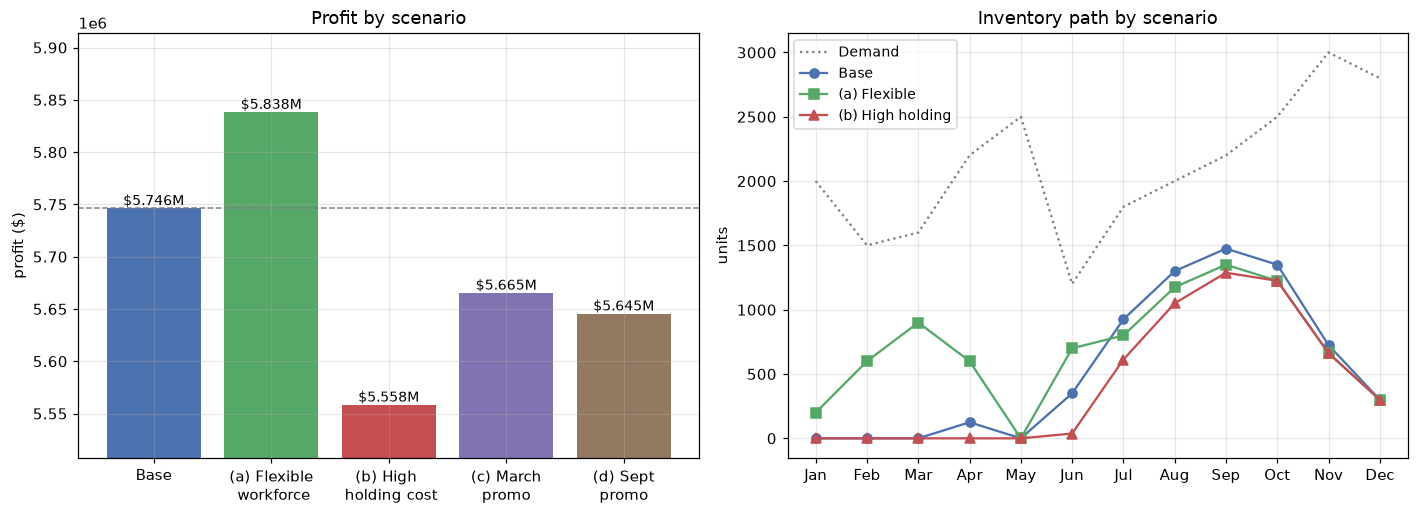

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
labels = ["Base", "(a) Flexible\n workforce", "(b) High \n holding cost",
          "(c) March\npromo", "(d) Sept\npromo"]
profits = summary["Profit"].values
colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b2", "#937860"]

bars = axes[0].bar(labels, profits, color=colors)
pad = (profits.max() - profits.min()) * 0.18
axes[0].set_ylim(profits.min() - pad, profits.max() + pad * 1.5)
for bar, v in zip(bars, profits):
    axes[0].annotate(f"${v/1e6:.3f}M", (bar.get_x() + bar.get_width() / 2, v),
                     ha="center", va="bottom", fontsize=9)
axes[0].axhline(base.profit, ls="--", color="grey", lw=1)
axes[0].set(ylabel="profit ($)", title="Profit by scenario")

xpos = np.arange(len(MONTHS))
axes[1].plot(xpos, base.table["Demand"], ":", color="grey", lw=1.5, label="Demand")
axes[1].plot(xpos, base.table["Inventory"], "o-", label="Base", color="#4c72b0")
axes[1].plot(xpos, flexible.table["Inventory"], "s-", label="(a) Flexible", color="#55a868")
axes[1].plot(xpos, costly_storage.table["Inventory"], "^-", label="(b) High holding", color="#c44e52")
axes[1].set_xticks(xpos); axes[1].set_xticklabels(MONTH_NAMES)
axes[1].set(ylabel="units", title="Inventory path by scenario")
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

## 10. Conclusions

- **The base plan is a level strategy by necessity.** With the workforce frozen at 25 and capacity capped at 2,375 units a month, inventory is the only mechanism for shifting production into the November–December peak. The plan builds stock through the quiet months and runs no overtime and no backlogs at all.
- **Workforce flexibility is worth about `$92,000`.** Allowing hiring at `$3,000` and layoffs at `$8,000` moves the plan from level to chase, 5 workers out in January, 5 back in August, and the `$55,000` spent on adjustment is more than repaid in wages and holding cost.
- **Cheap storage is what the base plan runs on.** Raising the holding cost from `$6` to `$40` costs roughly `$188,000` in profit and changes behaviour qualitatively: less stock, more overtime, and a deliberate 125-unit backlog in May where paying the late-delivery penalty beats paying to store.
- **Neither promotion is worth running.** Both raise revenue and both lower profit, September more so than March, because it sits against months that are already capacity-tight and applies the discount to a larger volume. If a promotion were mandated for other reasons, March is the cheaper month to run it in.